In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import uniform
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
import corner
import math
from tqdm import tqdm

In [4]:
# Get the data
data1 = np.loadtxt("HARPS.dat")
data2 = np.loadtxt("HIRES.dat")
data = np.vstack((data1,data2))
print(len(data1),' HARPS points; ',len(data2),' HIRES points')

# Add on jitter (additional noise term)
jitter = 1.2
for i in range(len(data)):
    data[i,2] = np.sqrt( data[i,2]**2 + jitter**2 )

# Initial information from Vogt et al. (2010)
Pb_sol = 5.36841; Pb_del = 0.00026; Kb_sol = 12.45
Pc_sol = 12.9191; Pc_del = 0.0058;  Kc_sol = 3.30
Pd_sol = 66.87;   Pd_del = 0.13;    Kd_sol = 1.91
Pe_sol = 3.14867; Pe_del = 0.00039; Ke_sol = 1.66
Pf_sol = 433.0;   Pf_del = 13.0;    Kf_sol = 1.30
Pg_sol = 36.562;  Pg_del = 0.052;   Kg_sol = 1.29

119  HARPS points;  122  HIRES points


In [5]:
# A full fit is tricky because it's not obvious where to initalize the phases (q) from
# So let's run a pre-fit first, where we only allow the phases to vary
# Trying running this a few times and make sure the same solution is coming out

# Define model M0 fix = 4-planet model using K & P parameters fixed to the Vogt+ reported values
def M0fix(t, qb, qc, qd, qe):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) \
           + Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) \
           + Kd_sol*np.sin(2.0*np.pi*t/Pd_sol+qd) \
           + Ke_sol*np.sin(2.0*np.pi*t/Pe_sol+qe)

# Define our parameters bounds
param_bounds = ([-2.0*np.pi, \
                  -2.0*np.pi, \
                  -2.0*np.pi, \
                  -2.0*np.pi],\
                 [2.0*np.pi, \
                  2.0*np.pi, \
                  2.0*np.pi, \
                  2.0*np.pi] )

# Give an intial guess to help the fitting routine
initial_guess = [np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
M0fix_best, M0fix_cov = curve_fit(M0fix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    M0fix(data[i,0],M0fix_best[0],M0fix_best[1],
                          M0fix_best[2],M0fix_best[3])) / data[i,2])**2

# Print output
print(chi2,len(data))

395.79612572684226 241


In [6]:
# OK, I'm satisfied the above chi2 looks reasonable, so set the phase solutions as initial guesses
qb_sol = M0fix_best[0]
qc_sol = M0fix_best[1]
qd_sol = M0fix_best[2]
qe_sol = M0fix_best[3]

In [7]:
# Now we're ready to run the full 4-planet fit

# Define model M0 = 4-planet model
def M0(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd, Ke, Pe, qe):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) \
           + Kc*np.sin(2.0*np.pi*t/Pc+qc) \
           + Kd*np.sin(2.0*np.pi*t/Pd+qd) \
           + Ke*np.sin(2.0*np.pi*t/Pe+qe)

# Define our parameters bounds
param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi])

# Give an intial guess to help the fitting routine
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol,
                 Kd_sol, Pd_sol, qd_sol,
                 Ke_sol, Pe_sol, qe_sol]

# Get the best fitting parameters
M0_best, M0_cov = curve_fit(M0,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    M0(data[i,0],M0_best[0],M0_best[1],M0_best[2],
                       M0_best[3],M0_best[4],M0_best[5],M0_best[6],
                       M0_best[7],M0_best[8],M0_best[9],M0_best[10],
                       M0_best[11]) ) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print(chi2,loglike)

390.3946367583786 -567.7796182652578


In [8]:
# Calculate the reduced chi2
chi2_red_M0 = 0.0
for i in range(len(data)):
    chi2_red_M0 = chi2_red_M0 + ((data[i,1] - \
                                  M0(data[i,0],M0_best[0],M0_best[1],M0_best[2],
                                     M0_best[3],M0_best[4],M0_best[5],M0_best[6],
                                     M0_best[7],M0_best[8],M0_best[9],M0_best[10],
                                     M0_best[11]) ) / data[i,2])**2
chi2_red_M0 = chi2_red_M0 / (len(data)-12)
print("Reduced χ2:\t", chi2_red_M0)

# Calculate the BIC
bic_M0 = -2 * loglike + 12*np.log(len(data))
aic_M0 = -2 * loglike + 2*12
print("BIC:\t\t", bic_M0)
print("AIC\t\t", aic_M0)

Reduced χ2:	 1.7047800731806926
BIC:		 1201.3767997324035
AIC		 1159.5592365305156


In [9]:
# _Mffix Model
# Pre-fit of the 5-planet model with shifting phase values
def Mffix(t, qb, qc, qd, qe, qf):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) + \
            Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) + \
            Kd_sol*np.sin(2.0*np.pi*t/Pd_sol+qd) + \
            Ke_sol*np.sin(2.0*np.pi*t/Pe_sol+qe) + \
            Kf_sol*np.sin(2.0*np.pi*t/Pf_sol+qf)

# Define our parameters bounds and initial guess
param_bounds = ([-2.0*np.pi, 
                  -2.0*np.pi, 
                  -2.0*np.pi, 
                  -2.0*np.pi, 
                  -2.0*np.pi],
                 [2.0*np.pi, 
                  2.0*np.pi, 
                  2.0*np.pi, 
                  2.0*np.pi, 
                  2.0*np.pi])

initial_guess = [np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
Mffix_best, Mffix_cov = curve_fit(Mffix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2 and assign corresponding phases
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ( ( data[i,1] - \
                     Mffix(data[i,0], Mffix_best[0], Mffix_best[1], Mffix_best[2],
                           Mffix_best[3], Mffix_best[4]) ) / data[i,2])**2
    
qb_sol = Mffix_best[0]
qc_sol = Mffix_best[1]
qd_sol = Mffix_best[2]
qe_sol = Mffix_best[3]
qf_sol = Mffix_best[4]

In [10]:
# _Mf Model
def Mf(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd, Ke, Pe, qe, Kf, Pf, qf):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + Kc*np.sin(2.0*np.pi*t/Pc+qc) + Kd*np.sin(2.0*np.pi*t/Pd+qd) \
           + Ke*np.sin(2.0*np.pi*t/Pe+qe) + Kf*np.sin(2.0*np.pi*t/Pf+qf)

# Define our parameters bounds
param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                 0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                 20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi])

# Give an intial guess to help the fitting routine
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol,
                 Kd_sol, Pd_sol, qd_sol,
                 Ke_sol, Pe_sol, qe_sol,
                 Kf_sol, Pf_sol, qf_sol]

# Get the best fitting parameters
Mf_best, Mf_cov = curve_fit(Mf,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mf(data[i,0],Mf_best[0],Mf_best[1],Mf_best[2],
                       Mf_best[3],Mf_best[4],Mf_best[5],Mf_best[6],
                       Mf_best[7],Mf_best[8],Mf_best[9],Mf_best[10],
                       Mf_best[11],Mf_best[12],Mf_best[13],Mf_best[14])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

344.95839290390836 -545.0614963380227


In [11]:
# Calculate chi2_reduced, BIC, AIC for Mf
chi2_red_Mf = 0.0
for i in range(len(data)):
    chi2_red_Mf = chi2_red_Mf + ((data[i,1] - \
                                  Mf( data[i,0],Mf_best[0],Mf_best[1],Mf_best[2],
                                     Mf_best[3],Mf_best[4],Mf_best[5],Mf_best[6],
                                     Mf_best[7],Mf_best[8],Mf_best[9],Mf_best[10],
                                     Mf_best[11],Mf_best[12],Mf_best[13],Mf_best[14])) / data[i,2])**2
chi2_red_Mf = chi2_red_Mf / (len(data)-15)

# Calculate the BIC and AIC
bic_Mf = -2 * loglike + 15*np.log(len(data))
aic_Mf = -2 * loglike + 2*15

print(chi2_red_Mf, bic_Mf, aic_Mf)

# Approximation of Bayes factor with BIC and AIC
bic_M0Mf = np.exp(-0.5*(bic_M0-bic_Mf))
aic_M0Mf = np.exp(-0.5*(aic_M0-aic_Mf))

#print(chi2_red_Mf, bic_M0Mf, aic_M0Mf)

1.526364570371276 5.089446713462912e-07 2.7323004491032216e-09


In [12]:
# _Mgfix Model
def Mgfix(t, qb, qc, qd, qe, qg):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) + Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) + \
Kd_sol*np.sin(2.0*np.pi*t/Pd_sol+qd) + \
Ke_sol*np.sin(2.0*np.pi*t/Pe_sol+qe) + \
Kg_sol*np.sin(2.0*np.pi*t/Pg_sol+qg)

# Define our parameters bounds and initial guess
param_bounds = ( [-2.0*np.pi, -2.0*np.pi, 
                  -2.0*np.pi, -2.0*np.pi, 
                  -2.0*np.pi],
                 [2.0*np.pi, 2.0*np.pi, 
                  2.0*np.pi, 2.0*np.pi, 
                  2.0*np.pi])
initial_guess = [np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
Mgfix_best, Mgfix_cov = curve_fit(Mgfix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2 and assign corresponding phases
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mgfix(data[i,0], Mgfix_best[0], Mgfix_best[1],
                          Mgfix_best[2], Mgfix_best[3],Mgfix_best[4])) / data[i,2])**2

qb_sol = Mgfix_best[0]
qc_sol = Mgfix_best[1]
qd_sol = Mgfix_best[2]
qe_sol = Mgfix_best[3]
qg_sol = Mgfix_best[4]

In [13]:
# Define model Mf = 5-planet model
def Mg(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd, Ke, Pe, qe, Kg, Pg, qg):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + Kc*np.sin(2.0*np.pi*t/Pc+qc) + \
Kd*np.sin(2.0*np.pi*t/Pd+qd) + \
Ke*np.sin(2.0*np.pi*t/Pe+qe) + \
Kg*np.sin(2.0*np.pi*t/Pg+qg)

# Define our parameters bounds
param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                 0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                 20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])

# Give an intial guess to help the fitting routine
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol,
                 Kd_sol, Pd_sol, qd_sol,
                 Ke_sol, Pe_sol, qe_sol,
                 Kg_sol, Pg_sol, qg_sol]

# Get the best fitting parameters
Mg_best, Mg_cov = curve_fit(Mg,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                     Mg(data[i,0],Mg_best[0],Mg_best[1],Mg_best[2],
                        Mg_best[3],Mg_best[4],Mg_best[5],
                        Mg_best[6],Mg_best[7],Mg_best[8],
                        Mg_best[9],Mg_best[10],Mg_best[11],
                        Mg_best[12],Mg_best[13],Mg_best[14])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

341.9418465384334 -543.5532231552852


In [24]:
# Define model Mg = 5-planet model
def Mg(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd, Ke, Pe, qe, Kg, Pg, qg):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + Kc*np.sin(2.0*np.pi*t/Pc+qc) + \
Kd*np.sin(2.0*np.pi*t/Pd+qd) + \
Ke*np.sin(2.0*np.pi*t/Pe+qe) + \
Kg*np.sin(2.0*np.pi*t/Pg+qg)

# Define our parameters bounds
param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                 0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                 20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])

# Give an intial guess to help the fitting routine
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol,
                 Kd_sol, Pd_sol, qd_sol,
                 Ke_sol, Pe_sol, qe_sol,
                 Kg_sol, Pg_sol, qg_sol]

# Get the best fitting parameters
Mg_best, Mg_cov = curve_fit(Mg,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mg(data[i,0],Mg_best[0],Mg_best[1],Mg_best[2],
                       Mg_best[3],Mg_best[4],Mg_best[5],
                       Mg_best[6],Mg_best[7],Mg_best[8],
                       Mg_best[9],Mg_best[10],Mg_best[11],
                       Mg_best[12],Mg_best[13],Mg_best[14])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

100%|█████████████████████████████████████| 241/241 [00:00<00:00, 111055.51it/s]

341.6003982690512 -543.3824990205942


In [16]:
# Calculate chi2_reduced, BIC, AIC for Mg
chi2_red_Mg = 0.0
for i in range(len(data)):
    chi2_red_Mg = chi2_red_Mg + ((data[i,1] - \
                                  Mg(data[i,0],Mg_best[0],Mg_best[1],Mg_best[2],
                                     Mg_best[3],Mg_best[4],Mg_best[5],Mg_best[6],
                                     Mg_best[7],Mg_best[8],Mg_best[9],Mg_best[10],
                                     Mg_best[11],Mg_best[12],Mg_best[13],Mg_best[14])) / data[i,2])**2
    
chi2_red_Mg = chi2_red_Mg / (len(data)-15)

# Calculate the BIC and AIC
bic_Mg = -2 * loglike + 15*np.log(len(data))
aic_Mg = -2 * loglike + 2*15

print(chi2_red_Mg, bic_Mg, aic_Mg)

# Approximation of Bayes factor with BIC and AIC
bic_M0Mg = np.exp(-0.5*(bic_M0-bic_Mg))
aic_M0Mg = np.exp(-0.5*(aic_M0-aic_Mg))

#print(chi2_red_Mg, bic_M0Mg, aic_M0Mg)

1.5130170200815638 1.1262527157087675e-07 6.046356262645668e-10


In [17]:
# Approximation of Bayes factor with BIC and AIC
bic_MfMg = np.exp(-0.5*(bic_Mf-bic_Mg))
aic_MfMg = np.exp(-0.5*(aic_Mf-aic_Mg))

print(bic_MfMg, aic_MfMg)

0.2212917786779329 0.2212917786779329


In [18]:
# _Mfg Model
# Pre-fit of the 6-planet model with shifting phase values
def Mfgfix(t, qb, qc, qd, qe, qf, qg):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) + \
Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) + \
Kd_sol*np.sin(2.0*np.pi*t/Pd_sol+qd) + \
Ke_sol*np.sin(2.0*np.pi*t/Pe_sol+qe) + \
Kf_sol*np.sin(2.0*np.pi*t/Pf_sol+qf) + \
Kg_sol*np.sin(2.0*np.pi*t/Pg_sol+qg)

# Define our parameters bounds and initial guess
param_bounds = ([-2.0*np.pi, -2.0*np.pi,
                 -2.0*np.pi, -2.0*np.pi,
                 -2.0*np.pi, -2.0*np.pi],
                [2.0*np.pi, 2.0*np.pi, 
                 2.0*np.pi, 2.0*np.pi, 
                 2.0*np.pi, 2.0*np.pi])
initial_guess = [np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
Mfgfix_best, Mfgfix_cov = curve_fit(Mfgfix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2 and assign corresponding phases
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mfgfix(data[i,0],Mfgfix_best[0],Mfgfix_best[1],
                           Mfgfix_best[2],Mfgfix_best[3],Mfgfix_best[4],
                           Mfgfix_best[5])) / data[i,2])**2

qb_sol = Mfgfix_best[0]
qc_sol = Mfgfix_best[1]
qd_sol = Mfgfix_best[2]
qe_sol = Mfgfix_best[3]
qf_sol = Mfgfix_best[4]
qg_sol = Mfgfix_best[5]

In [19]:
# Define model Mfg = 6-planet model
def Mfg(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd, Ke, Pe, qe, Kf, Pf, qf, Kg, Pg, qg):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + \
Kc*np.sin(2.0*np.pi*t/Pc+qc) + \
Kd*np.sin(2.0*np.pi*t/Pd+qd) + \
Ke*np.sin(2.0*np.pi*t/Pe+qe) + \
Kf*np.sin(2.0*np.pi*t/Pf+qf) + \
Kg*np.sin(2.0*np.pi*t/Pg+qg)

# Define our parameters bounds
param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                 0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi,
                 0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                 20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi,
                 20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi] )

# Give an intial guess to help the fitting routine
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol,
                 Kd_sol, Pd_sol, qd_sol,
                 Ke_sol, Pe_sol, qe_sol,
                 Kf_sol, Pf_sol, qf_sol,
                 Kg_sol, Pg_sol, qg_sol]

# Get the best fitting parameters
Mfg_best, Mfg_cov = curve_fit(Mfg,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mfg(data[i,0],Mfg_best[0],Mfg_best[1],Mfg_best[2],
                        Mfg_best[3],Mfg_best[4],Mfg_best[5],
                        Mfg_best[6],Mfg_best[7],Mfg_best[8],
                        Mfg_best[9],Mfg_best[10],Mfg_best[11],
                        Mfg_best[12],Mfg_best[13],Mfg_best[14],
                        Mfg_best[15],Mfg_best[16],Mfg_best[17])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

297.53667094729246 -521.3506353597147


In [20]:
# Calculate chi2_reduced, BIC, AIC for Mfg
chi2_red_Mfg = 0.0
for i in range(len(data)):
    chi2_red_Mfg = chi2_red_Mfg + ((data[i,1] - \
                                    Mfg(data[i,0],Mfg_best[0],Mfg_best[1],Mfg_best[2],
                                        Mfg_best[3],Mfg_best[4],Mfg_best[5],Mfg_best[6],
                                        Mfg_best[7],Mfg_best[8],Mfg_best[9],Mfg_best[10],
                                        Mfg_best[11],Mfg_best[12],Mfg_best[13],Mfg_best[14],
                                        Mfg_best[15],Mfg_best[16],Mfg_best[17])) / data[i,2])**2
    
chi2_red_Mfg = chi2_red_Mfg / (len(data)-15)

# Calculate the BIC and AIC
bic_Mfg = -2 * loglike + 18*np.log(len(data))
aic_Mfg = -2 * loglike + 2*18

print(chi2_red_Mfg, bic_Mfg, aic_Mfg)

# Approximation of Bayes factor with BIC and AIC
bic_M0Mfg = np.exp(-0.5*(bic_M0-bic_Mfg))
aic_M0Mfg = np.exp(-0.5*(aic_M0-aic_Mfg))

print(chi2_red_Mfg, bic_M0Mfg, aic_M0Mfg)

1.316533942244657 9.598426673307616e-14 2.7664053458044186e-18


In [21]:
# Approximation of Bayes factor with BIC and AIC
bic_MgMfg = np.exp(-0.5*(bic_Mg-bic_Mfg))
aic_MgMfg = np.exp(-0.5*(aic_Mg-aic_Mfg))

print(bic_MgMfg, aic_MgMfg)
# As both BIC_Mg_Mfg and AIC_Mg_Mfg are smaller than one, BIC_Mg and AIC_Mg are both greater than BIC_Mfg and AIC_Mfg
# This implies that the model Mfg is preferred with respect to Mg

8.522444864665374e-07 4.575326404259776e-09


# Section 2

In [252]:
M0_points1 = 0
Mf_points1 = 0
Mg_points1 = 0
Mfg_points1 = 0

param_bounds_M0 = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 
                    0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi, 
                    20.0, Pe_sol+3.0*Pe_del, 2.0*np.pi])
initial_guess_M0 = [Kb_sol, Pb_sol, qb_sol, 
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol]

param_bounds_Mf = ([0.0, Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0, Pc_sol-3.0*Pc_del, -2.0*np.pi, 
                    0.0, Pd_sol-3.0*Pd_del, -2.0*np.pi,
                    0.0, Pe_sol-3.0*Pe_del, -2.0*np.pi, 
                    0.0, Pf_sol-3.0*Pf_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                    20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi])
initial_guess_Mf = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol,
                    Kf_sol, Pf_sol, qf_sol]

param_bounds_Mg = ([0.0, Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0, Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0, Pd_sol-3.0*Pd_del, -2.0*np.pi, 
                    0.0, Pe_sol-3.0*Pe_del, -2.0*np.pi,
                    0.0, Pg_sol-3.0*Pg_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                    20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])
initial_guess_Mg = [Kb_sol, Pb_sol, qb_sol, 
                    Kc_sol, Pc_sol, qc_sol, 
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol, 
                    Kg_sol, Pg_sol, qg_sol]

param_bounds_Mfg = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                     0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                     0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 
                     0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                     0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi,
                     0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                     [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                      20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                      20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                      20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                      20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi, 
                      20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])
initial_guess_Mfg = [Kb_sol, Pb_sol, qb_sol, 
                     Kc_sol, Pc_sol, qc_sol, 
                     Kd_sol, Pd_sol, qd_sol,
                     Ke_sol, Pe_sol, qe_sol, 
                     Kf_sol, Pf_sol, qf_sol, 
                     Kg_sol, Pg_sol, qg_sol]

for a in tqdm(range(10000)):
    np.take(data,np.random.permutation(data.shape[0]),axis=0,out=data)
    validation_data = data[0:30]
    training_data = data[np.setdiff1d(np.array(list(range(len(data)))), np.array(list(range(0,30))))]

    # Find loglike for _M0
    M0_best, M0_cov = curve_fit(M0,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_M0,bounds=param_bounds_M0)
    residuals = validation_data[:,1] - M0(validation_data[:,0], *M0_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_M0 = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Find loglike for _Mf
    Mf_best, Mf_cov = curve_fit(Mf,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mf,bounds=param_bounds_Mf)
    residuals = validation_data[:,1] - Mf(validation_data[:,0], *Mf_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_Mf = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Find loglike for _Mg
    Mg_best, Mg_cov = curve_fit(Mg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mg,bounds=param_bounds_Mg)
    residuals = validation_data[:,1] - Mg(validation_data[:,0], *Mg_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_Mg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Find loglike for _Mfg
    Mfg_best, Mfg_cov = curve_fit(Mfg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mfg, bounds=param_bounds_Mfg)
    residuals = validation_data[:,1] - Mfg(validation_data[:,0], *Mfg_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_Mfg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Give a point to the model with maximum likelihood
    if max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_M0:
        M0_points1 += 1
    elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mf:
        Mf_points1 += 1
    elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mg:
        Mg_points1 += 1
    elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mfg:
        Mfg_points1 += 1

print(M0_points1,Mf_points1,Mg_points1,Mfg_points1)

100%|█████████████████████████████████████| 10000/10000 [19:22<00:00,  8.60it/s]

294 1248 1517 6941


In [260]:
M0_points2 = 0
Mf_points2 = 0
Mg_points2 = 0
Mfg_points2 = 0

param_bounds_M0 = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 
                    0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi, 
                    20.0, Pe_sol+3.0*Pe_del, 2.0*np.pi])
initial_guess_M0 = [Kb_sol, Pb_sol, qb_sol, 
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol]

param_bounds_Mf = ([0.0, Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0, Pc_sol-3.0*Pc_del, -2.0*np.pi, 
                    0.0, Pd_sol-3.0*Pd_del, -2.0*np.pi,
                    0.0, Pe_sol-3.0*Pe_del, -2.0*np.pi, 
                    0.0, Pf_sol-3.0*Pf_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                    20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi])
initial_guess_Mf = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol,
                    Kf_sol, Pf_sol, qf_sol]

param_bounds_Mg = ([0.0, Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0, Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0, Pd_sol-3.0*Pd_del, -2.0*np.pi, 
                    0.0, Pe_sol-3.0*Pe_del, -2.0*np.pi,
                    0.0, Pg_sol-3.0*Pg_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                    20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])
initial_guess_Mg = [Kb_sol, Pb_sol, qb_sol, 
                    Kc_sol, Pc_sol, qc_sol, 
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol, 
                    Kg_sol, Pg_sol, qg_sol]

param_bounds_Mfg = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                     0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                     0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 
                     0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                     0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi,
                     0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                     [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                      20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                      20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                      20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                      20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi, 
                      20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])
initial_guess_Mfg = [Kb_sol, Pb_sol, qb_sol, 
                     Kc_sol, Pc_sol, qc_sol, 
                     Kd_sol, Pd_sol, qd_sol,
                     Ke_sol, Pe_sol, qe_sol, 
                     Kf_sol, Pf_sol, qf_sol, 
                     Kg_sol, Pg_sol, qg_sol]

for a in tqdm(range(10000)):
    np.take(data,np.random.permutation(data.shape[0]),axis=0,out=data)
    validation_data = data[0:60]
    training_data = data[np.setdiff1d(np.array(list(range(len(data)))), np.array(list(range(0,60))))]

    # Find loglike for _M0
    M0_best, M0_cov = curve_fit(M0,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_M0,bounds=param_bounds_M0)
    residuals = validation_data[:,1] - M0(validation_data[:,0], *M0_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_M0 = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Find loglike for _Mf
    Mf_best, Mf_cov = curve_fit(Mf,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mf,bounds=param_bounds_Mf)
    residuals = validation_data[:,1] - Mf(validation_data[:,0], *Mf_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_Mf = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Find loglike for _Mg
    Mg_best, Mg_cov = curve_fit(Mg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mg,bounds=param_bounds_Mg)
    residuals = validation_data[:,1] - Mg(validation_data[:,0], *Mg_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_Mg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Find loglike for _Mfg
    Mfg_best, Mfg_cov = curve_fit(Mfg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mfg, bounds=param_bounds_Mfg)
    residuals = validation_data[:,1] - Mfg(validation_data[:,0], *Mfg_best)
    chi2 = np.sum((residuals / validation_data[:,2])**2)
    loglike_Mfg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum(np.log(validation_data[:,2])) - 0.5*chi2

    # Give a point to the model with maximum likelihood
    if max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_M0:
        M0_points2 += 1
    elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mf:
        Mf_points2 += 1
    elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mg:
        Mg_points2 += 1
    elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mfg:
        Mfg_points2 += 1

print(M0_points2,Mf_points2,Mg_points2,Mfg_points2)

100%|█████████████████████████████████████| 10000/10000 [19:33<00:00,  8.52it/s]

85 745 878 8292


In [267]:
M0_points3 = 0
Mf_points3 = 0
Mg_points3 = 0
Mfg_points3 = 0

for a in tqdm(range(1000)):
    np.take(data,np.random.permutation(data.shape[0]),axis=0,out=data)
    for i in range(len(data)//24):
        validation_data = data[i:i+10]
        training_data = data[np.setdiff1d(np.array(list(range(len(data)))), np.array(list(range(i,i+10))))]

        # Find loglike for M0
        param_bounds = ( [0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi, \
                          0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi],\
                     [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, \
                      20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi, 20.0, Pe_sol+3.0*Pe_del, 2.0*np.pi] )
        initial_guess = [ Kb_sol, Pb_sol, qb_sol, Kc_sol, Pc_sol, qc_sol, Kd_sol, Pd_sol, qd_sol,\
                      Ke_sol, Pe_sol, qe_sol]

        M0_best, M0_cov = curve_fit(M0,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess,bounds=param_bounds)

        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ( ( validation_data[i,1] - M0( validation_data[i,0], M0_best[0],M0_best[1],M0_best[2], M0_best[3],M0_best[4],M0_best[5],\
                                          M0_best[6],M0_best[7],M0_best[8], M0_best[9],M0_best[10],M0_best[11]) ) / training_data[i,2])**2
        loglike_M0 = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2


        # Find loglike for Mf
        param_bounds = ( [0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi, 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, \
                      0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi, 0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi],\
                     [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, \
                      20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi, 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, \
                      20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi] )
        initial_guess = [ Kb_sol, Pb_sol, qb_sol,\
                      Kc_sol, Pc_sol, qc_sol,\
                      Kd_sol, Pd_sol, qd_sol,\
                      Ke_sol, Pe_sol, qe_sol,\
                      Kf_sol, Pf_sol, qf_sol]
        Mf_best, Mf_cov = curve_fit(Mf,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess,bounds=param_bounds)

        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ( ( validation_data[i,1] - Mf( validation_data[i,0], Mf_best[0],Mf_best[1],Mf_best[2], Mf_best[3],Mf_best[4],Mf_best[5],\
                                Mf_best[6],Mf_best[7],Mf_best[8], Mf_best[9],Mf_best[10],Mf_best[11],\
                                Mf_best[12],Mf_best[13],Mf_best[14]) ) / training_data[i,2])**2
        loglike_Mf = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

        # Find loglike for Mg
        param_bounds = ( [0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi, \
                          0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi, \
                          0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],\
                     [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi, \
                      20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi] )
        initial_guess = [ Kb_sol, Pb_sol, qb_sol, Kc_sol, Pc_sol, qc_sol, Kd_sol, Pd_sol, qd_sol,\
                      Ke_sol, Pe_sol, qe_sol, Kg_sol, Pg_sol, qg_sol]

        Mg_best, Mg_cov = curve_fit(Mg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess,bounds=param_bounds)

        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ( ( validation_data[i,1] - Mg( validation_data[i,0], Mg_best[0],Mg_best[1],Mg_best[2], Mg_best[3],Mg_best[4],Mg_best[5],\
                                    Mg_best[6],Mg_best[7],Mg_best[8], Mg_best[9],Mg_best[10],Mg_best[11],\
                                    Mg_best[12],Mg_best[13],Mg_best[14]) ) / training_data[i,2])**2
        loglike_Mg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

        # Find loglike for Mfg
        param_bounds = ( [0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi, \
                          0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi, 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi, \
                          0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi, 0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],\
                     [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi, \
                      20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi, 20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi] )
        initial_guess = [ Kb_sol, Pb_sol, qb_sol, Kc_sol, Pc_sol, qc_sol, Kd_sol, Pd_sol, qd_sol,\
                      Ke_sol, Pe_sol, qe_sol, Kf_sol, Pf_sol, qf_sol, Kg_sol, Pg_sol, qg_sol]

        Mfg_best, Mfg_cov = curve_fit(Mfg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess,bounds=param_bounds)

        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ( ( validation_data[i,1] - Mfg( validation_data[i,0], Mfg_best[0],Mfg_best[1],Mfg_best[2], Mfg_best[3],Mfg_best[4],Mfg_best[5],\
                                          Mfg_best[6],Mfg_best[7],Mfg_best[8], Mfg_best[9],Mfg_best[10],Mfg_best[11],\
                                          Mfg_best[12],Mfg_best[13],Mfg_best[14], Mfg_best[15],Mfg_best[16],Mfg_best[17]) ) / training_data[i,2])**2
        loglike_Mfg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

        # Give a point to the model with maximum likelihood
        if max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_M0:
            M0_points3 += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mf:
            Mf_points3 += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mg:
            Mg_points3 += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg) == loglike_Mfg:
            Mfg_points3 += 1

print(M0_points3,Mf_points3,Mg_points3,Mfg_points3)

100%|███████████████████████████████████████| 1000/1000 [17:16<00:00,  1.04s/it]

907 1851 2576 4666


In [268]:
# Summary of cross-validation results:
model_values = np.array([[M0_points1,Mf_points1,Mg_points1,Mfg_points1,
                          M0_points2,Mf_points2,Mg_points2,Mfg_points2,
                          M0_points3,Mf_points3,Mg_points3,Mfg_points3]]).reshape(3,4).T
model_values

array([[ 294,   85,  907],
       [1248,  745, 1851],
       [1517,  878, 2576],
       [6941, 8292, 4666]])

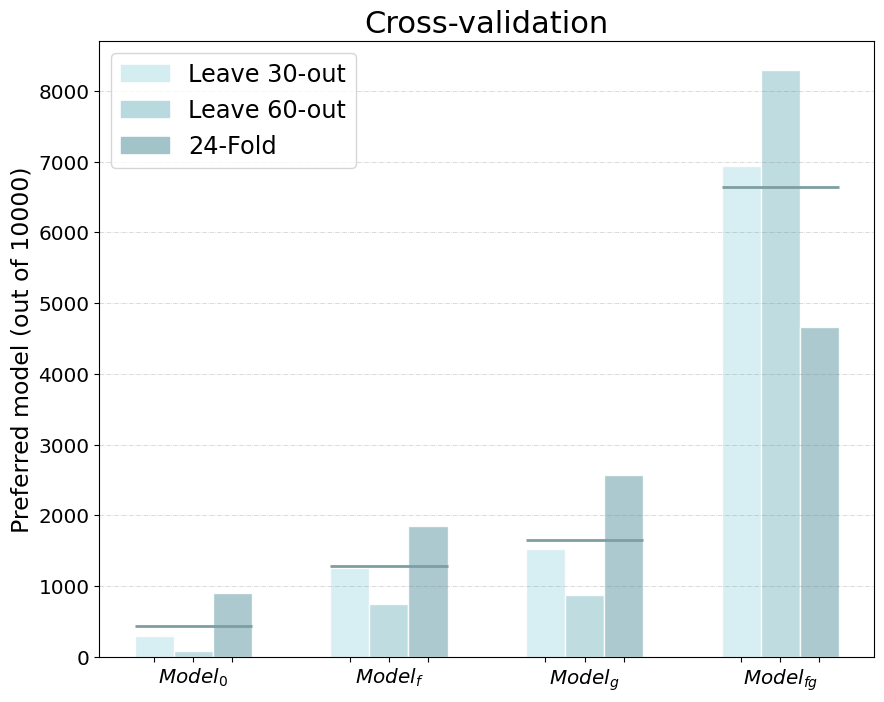

In [269]:
fig = plt.figure(figsize=(10,8))

plt.bar([0.8, 1, 1.2, 1.8, 2, 2.2, 2.8, 3, 3.2, 3.8, 4, 4.2], 
        [model_values[0,0], model_values[0,1], model_values[0,2],
         model_values[1,0], model_values[1,1], model_values[1,2],  
         model_values[2,0], model_values[2,1], model_values[2,2],  
         model_values[3,0], model_values[3,1], model_values[3,2]],
        width=0.2, tick_label = ['', r'$Model_{0}$', '', '', r'$Model_{f}$', '',
                                 '', r'$Model_{g}$', '',  '',r'$Model_{fg}$',''], 
        color = ['#d3edf1ff', '#b8d9deff', '#a2c4c9ff',  
                 '#d3edf1ff', '#b8d9deff', '#a2c4c9ff', 
                 '#d3edf1ff', '#b8d9deff', '#a2c4c9ff'], 
        edgecolor = 'white', alpha = 0.9)

plt.ylabel('Preferred model (out of 10000)', fontsize=17)

ax = plt.gca()

mean = \
ax.hlines(y = np.mean(model_values[0,:]), xmin=0.7, xmax=1.3, linewidth=2, color = '#7d9ea2ff')
ax.hlines(y = np.mean(model_values[1,:]), xmin=1.7, xmax=2.3, linewidth=2, color = '#7d9ea2ff')
ax.hlines(y = np.mean(model_values[2,:]), xmin=2.7, xmax=3.3, linewidth=2, color = '#7d9ea2ff')
ax.hlines(y = np.mean(model_values[3,:]), xmin=3.7, xmax=4.3, linewidth=2, color = '#7d9ea2ff')

ax.grid(axis='y', color='grey', linestyle='-.', linewidth=0.5, alpha = 0.4)
ax.yaxis.set_tick_params(labelsize='x-large')
ax.xaxis.set_tick_params(labelsize='x-large')

colors = {'Leave 30-out':'#d3edf1ff', 'Leave 60-out':'#b8d9deff', '24-Fold': '#a2c4c9ff'}         
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels, loc = 'upper left', fontsize = 'xx-large')

plt.title('Cross-validation', fontsize = 22)
fig.savefig("Cross-validation.png", bbox_inches='tight', dpi=600)

plt.show()

In [270]:
np.mean(model_values[0,:]), np.mean(model_values[1,:]), np.mean(model_values[2,:]), np.mean(model_values[3,:])

(428.6666666666667, 1281.3333333333333, 1657.0, 6633.0)

In [55]:
# We start by trying to define a model for 1 planet as we have done previously.
def M1fix(t, qb):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) 
param_bounds = ( [-2.0*np.pi], [2.0*np.pi] )
initial_guess = [ np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
M1fix_best, M1fix_cov = curve_fit(M1fix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + (data[i,1] - M1fix(data[i,0], M1fix_best[0]) / data[i,2])**2
print(chi2)

# This high chi2 result prompts us to think about other ways of obtaining the parameters for the 1-planet system

7459.237573465781


100%|██████████████████████████████████| 99999/99999 [00:04<00:00, 20169.80it/s]


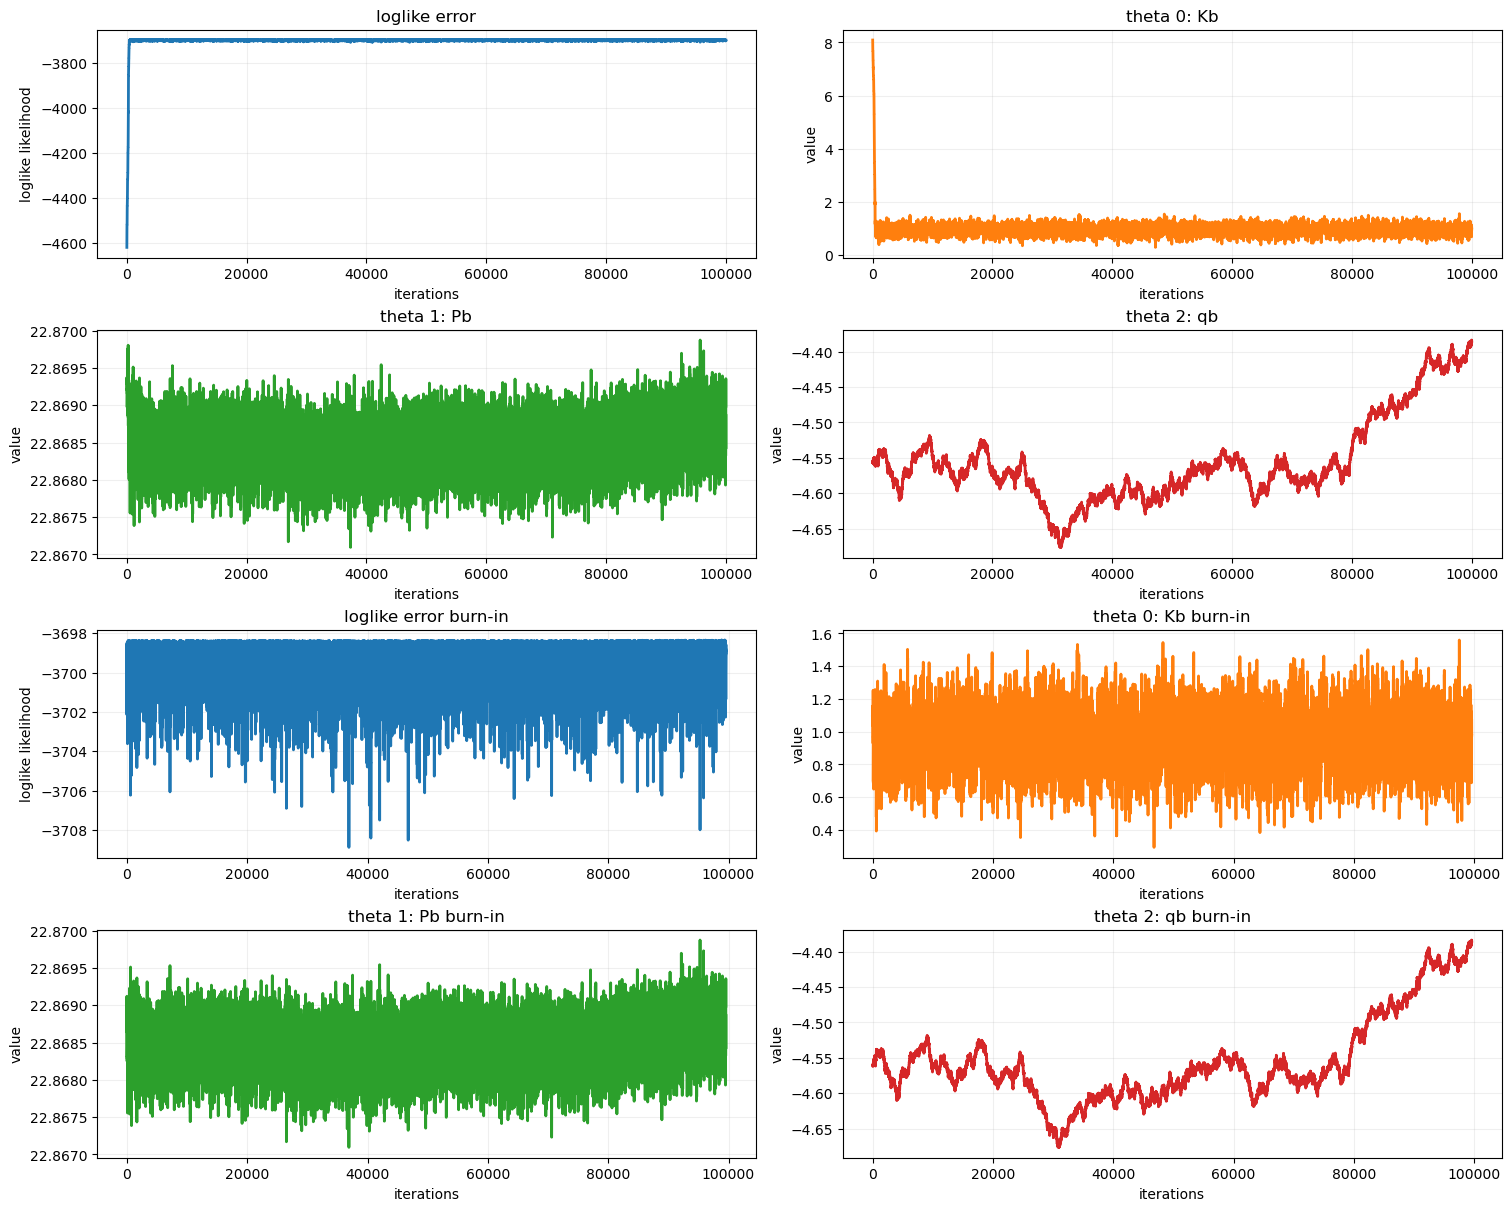

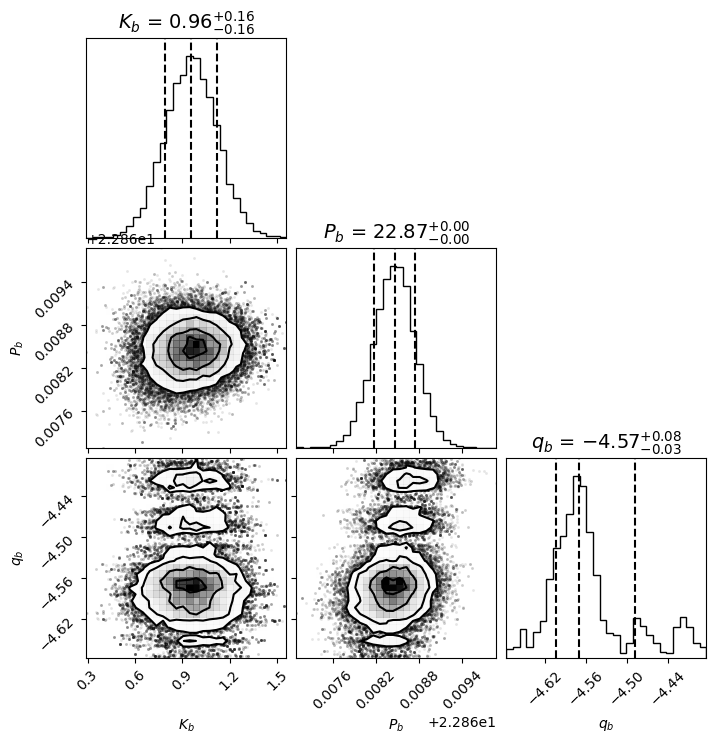

In [258]:
def model(t, theta):
    return theta[0] * np.sin(2.0 * np.pi * t / theta[1] + theta[2])

def log_like(data, theta):
    y_model = model(data[:, 0], theta)
    loglike = -0.5 * np.log(2 * np.pi) - np.log(data[:, 2]) - 0.5 * ((data[:, 1] - y_model) / data[:, 2]) ** 2
    return np.sum(loglike)

def log_prior(theta, thetaspace):
    logprior = 0.0
    # Prior for theta[0]: Kb~logU[0, 20]
    if thetaspace[0][0] <= theta[0] < thetaspace[0][1]:
        logprior += -np.log(thetaspace[0][1] - thetaspace[0][0])
    else:
        return 1e-50000

    # Prior for theta[1]: Pb~logU[0, 100]
    if thetaspace[1][0] <= theta[1] < thetaspace[1][1]:
        logprior += -np.log(thetaspace[1][1] - thetaspace[1][0])
    else:
        return 1e-50000

    # Prior for theta[2]: qb~logU[-2pi, 2pi]
    if thetaspace[2][0] <= theta[2] < thetaspace[2][1]:
        logprior += -np.log(thetaspace[2][1] - thetaspace[2][0])
    else:
        return 1e-50000
    
    return logprior

# Initialize the MCMC from a random point drawn from the prior
#Kb_sol = 12.45, Pb_sol = 5.36841
#Kb
min0, max0 = 0, 20

#Pb
min1, max1 = 20, 26

#qb
min2, max2 = -2*np.pi, 2*np.pi

prior_params = np.array((min0, max0, min1, max1, min2, max2)).reshape(3, 2)

theta0 = np.random.uniform(min0, max0)
theta1 = np.random.uniform(min1, max1)
theta2 = np.random.uniform(min2, max2)

theta = np.array([theta0, theta1, theta2])

mod_loglike = log_like(data, theta)
mod_logp = mod_loglike + log_prior(theta, prior_params)

# Define proposal jump size:
delta = [0.1, 0.001, 0.001]

# Start walking
jmax = 100000
theta_j = np.zeros((jmax, 3))
loglike_j = np.zeros(jmax)
logp_j = np.zeros(jmax)

theta_j[0] = theta
loglike_j[0] = mod_loglike
logp_j[0] = mod_logp

for j in tqdm(range(1,jmax)):
    
    # Generate a proposal with a normal distribution with sigma the previously proposed jump size
    theta_trial = np.random.normal(theta_j[j - 1], np.abs(delta))
    loglike_trial = log_like(data, theta_trial)
    logp_trial = loglike_trial + log_prior(theta_trial, prior_params)

    # Compute Metropolis rule
    if loglike_trial > loglike_j[j - 1] or np.random.rand() < np.exp(loglike_trial - loglike_j[j - 1]):
        theta_j[j] = theta_trial
        loglike_j[j] = loglike_trial
    else:
        theta_j[j] = theta_j[j - 1]
        loglike_j[j] = loglike_j[j - 1]
        logp_j[j] = logp_j[j - 1]
    
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = loglike_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if loglike_j[i] > median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []
theta_j_2 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    theta_j_2.append(i[2])
    iters = loglike_j[0]

theta_j = np.array(theta_j)
theta_names = ['theta 1', 'theta 2', 'theta 3']

fig, axs = plt.subplots(4, 2, figsize=(15, 12), constrained_layout=True)
plt.ticklabel_format(useOffset=False)

axs[0, 0].plot(loglike_j, 'tab:blue', linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, 'tab:orange', linewidth=2)
axs[0, 1].set_title('theta 0: Kb')
axs[0, 1].set_xlabel('iterations')
axs[0, 1].set_ylabel('value')

axs[1, 0].plot(theta_j_1, 'tab:green', linewidth=2)
axs[1, 0].set_title('theta 1: Pb')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('value')

axs[1, 1].plot(theta_j_2, 'tab:red', linewidth=2)
axs[1, 1].set_title('theta 2: qb')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(loglike_j[burn:], 'tab:blue', linewidth=2)
axs[2, 0].set_title('loglike error burn-in')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('loglike likelihood')

axs[2, 1].plot(theta_j_0[burn:], 'tab:orange', linewidth=2)
axs[2, 1].set_title('theta 0: Kb burn-in')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

axs[3, 0].plot(theta_j_1[burn:], 'tab:green', linewidth=2)
axs[3, 0].set_title('theta 1: Pb burn-in')
axs[3, 0].set_xlabel('iterations')
axs[3, 0].set_ylabel('value')

axs[3, 1].plot(theta_j_2[burn:], 'tab:red', linewidth=2)
axs[3, 1].set_title('theta 2: qb burn-in')
axs[3, 1].set_xlabel('iterations')
axs[3, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# Plot corner diagram of the gradients and y-intercepts to find their expected correlation.
num = jmax-burn

Kb = np.array(theta_j_0[burn:]).reshape(num,1)
Pb = np.array(theta_j_1[burn:]).reshape(num,1)
qb = np.array(theta_j_2[burn:]).reshape(num,1)

samples = np.hstack([Kb, Pb, qb])

figure = corner.corner(samples, bins=30, labels=[
        r"$K_b$",
        r"$P_b$",
        r"$q_b$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 14})

In [261]:
Kb_mean = np.mean(Kb)
Pb_mean = np.mean(Pb)
qb_mean = np.mean(qb)
Kb_mean, Pb_mean, qb_mean

(0.956704022348204, 22.868456143436475, -4.556091853989135)

In [218]:
def M1(t, Kb, Pb, qb):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) 

param_bounds = ([0.0,  23.54-3.0*0.01, -2.0*np.pi],
                [20.0, 23.54+3.0*0.01,  2.0*np.pi])
initial_guess = [1.36, 23.54, qb_sol]

# Get the best fitting parameters
M1_best, M1_cov = curve_fit(M1,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ( ( data[i,1] - M1( data[i,0],\
                                      M1_best[0],M1_best[1],M1_best[2]) ) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

6618.785884659687 -3681.975242215912


In [219]:
def M2fix(t, qb, qc):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) + \
Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) 
param_bounds = ([-2.0*np.pi, -2.0*np.pi], 
                [2.0*np.pi, 2.0*np.pi])
initial_guess = [np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
M2fix_best, M2fix_cov = curve_fit(M2fix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    M2fix(data[i,0],M2fix_best[0],
                          M2fix_best[1])) / data[i,2])**2

# It results in a chi2 value of 595, which is higher than expected, but we will still use the result.
qb_sol = M2fix_best[0]
qc_sol = M2fix_best[1]

def M2(t, Kb, Pb, qb, Kc, Pc, qc):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + \
Kc*np.sin(2.0*np.pi*t/Pc+qc)

param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi])
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol]

# Get the best fitting parameters
M2_best, M2_cov = curve_fit(M2,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    M2(data[i,0],M2_best[0],M2_best[1],M2_best[2],
                       M2_best[3],M2_best[4],M2_best[5])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

588.5393737628877 -666.8519867675125


In [220]:
def M3fix(t, qb, qc, qd):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) + \
Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) + \
Kd_sol*np.sin(2.0*np.pi*t/Pd_sol+qd)

param_bounds = ([-2.0*np.pi, 
                 -2.0*np.pi,
                 -2.0*np.pi],
                [2.0*np.pi, 
                 2.0*np.pi, 
                 2.0*np.pi])
initial_guess = [np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi)]

# Get the best fitting parameters
M3fix_best, M3fix_cov = curve_fit(M3fix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    M3fix(data[i,0], M3fix_best[0], M3fix_best[1], 
                          M3fix_best[2])) / data[i,2])**2

# It results in a chi2 value of 500, which is higher than expected, but we will still use the result.
qb_sol = M3fix_best[0]
qc_sol = M3fix_best[1]
qd_sol = M3fix_best[2]

def M3(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + \
Kc*np.sin(2.0*np.pi*t/Pc+qc) + \
Kd*np.sin(2.0*np.pi*t/Pd+qd)

param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi])
initial_guess = [Kb_sol, Pb_sol, qb_sol, 
                 Kc_sol, Pc_sol, qc_sol, 
                 Kd_sol, Pd_sol, qd_sol]

# Get the best fitting parameters
M3_best, M3_cov = curve_fit(M3,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    M3(data[i,0],M3_best[0],M3_best[1],M3_best[2],
                       M3_best[3],M3_best[4],M3_best[5],M3_best[6],
                       M3_best[7],M3_best[8])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

492.4529714832874 -618.8087856277123


In [240]:
M1_points = 0
M2_points = 0
M3_points = 0
M0_points = 0

# _M1
param_bounds_M1 = ([0.0,  23.54-3.0*0.01, -2.0*np.pi],
                   [20.0, 23.54+3.0*0.01,  2.0*np.pi])
initial_guess_M1 = [1.36, 23.54, qb_sol]

# _M2
param_bounds_M2 = ([0.0, Pb_sol-3.0*Pb_del, -2.0*np.pi,
                    0.0, Pc_sol-3.0*Pc_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del, 2.0*np.pi,
                    20.0, Pc_sol+3.0*Pc_del, 2.0*np.pi])
initial_guess_M2 = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol]

# _M3
param_bounds_M3 = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                    0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi])
initial_guess_M3 = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol]
# _M0
param_bounds_M0 = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                    0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                    0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del, 2.0*np.pi])
initial_guess_M0 = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol]

for a in tqdm(range(10000)):
    np.take(data,np.random.permutation(data.shape[0]),axis=0,out=data)
    validation_data = data[0:40]
    training_data = data[np.setdiff1d(np.array(list(range(len(data)))), np.array(list(range(0,40))))]
    
    # Find loglike for _M1
    M1_best, M1_cov = curve_fit(M1,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess_M1,bounds=param_bounds_M1)
    chi2 = 0.0
    for i in range(len(data)):
        chi2 = chi2 + ((data[i,1] - M1(data[i,0], M1_best[0],M1_best[1],M1_best[2]) ) / data[i,2])**2
    loglike_M1 = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2
     
    # Find loglike for _M2
    M2_best, M2_cov = curve_fit(M2,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess_M2,bounds=param_bounds_M2)
    chi2 = 0.0
    for i in range(len(data)):
        chi2 = chi2 + ((data[i,1] - M2(data[i,0],\
                                      M2_best[0],M2_best[1],M2_best[2],\
                                      M2_best[3],M2_best[4],M2_best[5]) ) / data[i,2])**2
    loglike_M2 = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2
    
    # Find loglike for _M3
    M3_best, M3_cov = curve_fit(M3,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess_M3,bounds=param_bounds_M3)
    chi2 = 0.0
    for i in range(len(data)):
        chi2 = chi2 + ( ( data[i,1] - M3( data[i,0],\
                                      M3_best[0],M3_best[1],M3_best[2],\
                                      M3_best[3],M3_best[4],M3_best[5],\
                                      M3_best[6],M3_best[7],M3_best[8]) ) / data[i,2])**2
    loglike_M3 = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2
    
    # Find loglike for _M0 
    M0_best, M0_cov = curve_fit(M0,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_M0,bounds=param_bounds_M0)
    chi2 = 0.0
    for i in range(len(validation_data)):
        chi2 = chi2 + ( ( validation_data[i,1] - M0( validation_data[i,0], M0_best[0],M0_best[1],M0_best[2], M0_best[3],M0_best[4],M0_best[5],\
                                          M0_best[6],M0_best[7],M0_best[8], M0_best[9],M0_best[10],M0_best[11]) ) / training_data[i,2])**2
    loglike_M0 = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

    # Give a point to the model with maximum likelihood
    if max(loglike_M1, loglike_M2, loglike_M3, loglike_M0) == loglike_M0:
        M0_points += 1
    elif max(loglike_M1, loglike_M2, loglike_M3, loglike_M0) == loglike_M1:
        M1_points += 1
    elif max(loglike_M1, loglike_M2, loglike_M3, loglike_M0) == loglike_M2:
        M2_points += 1
    elif max(loglike_M1, loglike_M2, loglike_M3, loglike_M0) == loglike_M3:
        M3_points += 1

print(M1_points,M2_points,M3_points,M0_points)

100%|█████████████████████████████████████| 10000/10000 [09:20<00:00, 17.84it/s]

0 0 0 10000


In [226]:
# Defining model Mh with an eccentric planet h.

def Mhefix(t, qb, qc, qd, qe, Kh, Ph, qh, eh):
    return Kb_sol*np.sin(2.0*np.pi*t/Pb_sol+qb) + \
Kc_sol*np.sin(2.0*np.pi*t/Pc_sol+qc) + \
Kd_sol*np.sin(2.0*np.pi*t/Pd_sol+qd) + \
Ke_sol*np.sin(2.0*np.pi*t/Pe_sol+qe) + \
Kh*np.cos(2.0*np.pi*t/Ph) + \
Kh*eh*np.cos(4.0*np.pi*t/Ph+qh) 

# Define our parameters bounds and initial guess
param_bounds = ([-2.0*np.pi, -2.0*np.pi,
                 -2.0*np.pi, -2.0*np.pi, 
                 0, 30, -2.0*np.pi, 0],
                [2.0*np.pi, 2.0*np.pi, 
                 2.0*np.pi, 2.0*np.pi, 
                 15, 400, 2.0*np.pi, 1])
initial_guess = [np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi), 
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(0, 5),
                 np.random.uniform(30,400), 
                 np.random.uniform(-np.pi,np.pi),
                 np.random.uniform(0,1)]

# Get the best fitting parameters
Mhefix_best, Mhefix_cov = curve_fit(Mhefix,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2 and assign corresponding phases
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mhefix(data[i,0], Mhefix_best[0], Mhefix_best[1], 
                           Mhefix_best[2], Mhefix_best[3], Mhefix_best[4], 
                           Mhefix_best[5], Mhefix_best[6], Mhefix_best[7])) / data[i,2])**2

qb_sol = Mhefix_best[0]
qc_sol = Mhefix_best[1]
qd_sol = Mhefix_best[2]
qe_sol = Mhefix_best[3]
Kh_sol = Mhefix_best[4]
Ph_sol, Ph_del = Mhefix_best[5], Mhefix_cov[5][5]
qh_sol = Mhefix_best[6]
eh_sol = Mhefix_best[7]

# Define model Mfg = 6-planet model
def Mhe(t, Kb, Pb, qb, Kc, Pc, qc, Kd, Pd, qd, Ke, Pe, qe, Kh, Ph, qh, eh):
    return Kb*np.sin(2.0*np.pi*t/Pb+qb) + \
Kc*np.sin(2.0*np.pi*t/Pc+qc) + \
Kd*np.sin(2.0*np.pi*t/Pd+qd) + \
Ke*np.sin(2.0*np.pi*t/Pe+qe) + \
Kh*np.cos(2.0*np.pi*t/Ph) + \
Kh*eh*np.cos(4.0*np.pi*t/Ph+qh) 

# Define our parameters bounds
param_bounds = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi, 
                 0.0,  Ph_sol-3.0*Ph_del, -2.0*np.pi, 0],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                 20.0, Ph_sol+3.0*Ph_del,  2.0*np.pi, 1])

# Give an intial guess to help the fitting routine
initial_guess = [Kb_sol, Pb_sol, qb_sol,
                 Kc_sol, Pc_sol, qc_sol,
                 Kd_sol, Pd_sol, qd_sol,
                 Ke_sol, Pe_sol, qe_sol,
                 Kh_sol, Ph_sol, qh_sol, eh_sol]

# Get the best fitting parameters
Mhe_best, Mhe_cov = curve_fit(Mhe,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess,bounds=param_bounds)

# Get the chi2
chi2 = 0.0
for i in range(len(data)):
    chi2 = chi2 + ((data[i,1] - \
                    Mhe(data[i,0],Mhe_best[0],Mhe_best[1],Mhe_best[2],
                        Mhe_best[3],Mhe_best[4],Mhe_best[5],
                        Mhe_best[6],Mhe_best[7],Mhe_best[8],
                        Mhe_best[9],Mhe_best[10],Mhe_best[11],
                        Mhe_best[12],Mhe_best[13],Mhe_best[14],
                        Mhe_best[15])) / data[i,2])**2
# Get the loglike
loglike = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

# Print output
print (chi2,loglike)

379.2855755733774 -562.2250876727572


In [227]:
# Calculate chi2_reduced, BIC, AIC for Mh
chi2_red_Mhe = 0.0
for i in range(len(data)):
    chi2_red_Mhe = chi2_red_Mhe + ((data[i,1] - \
                                    Mhe( data[i,0],Mhe_best[0],Mhe_best[1],Mhe_best[2],
                                        Mhe_best[3],Mhe_best[4],Mhe_best[5],
                                        Mhe_best[6],Mhe_best[7],Mhe_best[8],
                                        Mhe_best[9],Mhe_best[10],Mhe_best[11],
                                        Mhe_best[12],Mhe_best[13],Mhe_best[14], 
                                        Mhe_best[14]) ) / data[i,2])**2
    
chi2_red_Mhe = chi2_red_Mhe / (len(data)-15)

# Calculate the BIC and AIC
bic_Mhe = -2 * loglike + 15*np.log(len(data))
aic_Mhe = -2 * loglike + 2*15

# Approximation of Bayes factor with BIC and AIC
bic_MheMf = np.exp(-0.5*(bic_Mhe-bic_Mf))
aic_MheMf = np.exp(-0.5*(aic_Mhe-aic_Mf))

print(chi2_red_Mhe, bic_MheMf, aic_MheMf)
# As both BIC_Mhe_Mf and AIC_Mhe_Mf are smaller than one, BIC_Mhe and AIC_Mhe are both greater than BIC_Mf and AIC_Mf
# This implies that the model Mf is preferred with respect to Mhe

2.163802223256751 3.515175346476042e-08 3.515175346476042e-08


In [231]:
M0_points = 0
Mf_points = 0
Mg_points = 0
Mfg_points = 0
Mhe_points = 0

# _M0
param_bounds_M0 = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                    0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                    0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del, 2.0*np.pi])
initial_guess_M0 = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol]

# _Mf
param_bounds_Mf = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                 0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi, 
                 0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                 0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                 0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi],
                [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                 20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                 20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                 20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                 20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi])
initial_guess_Mf = [Kb_sol, Pb_sol, qb_sol,
                    Kc_sol, Pc_sol, qc_sol,
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol,
                    Kf_sol, Pf_sol, qf_sol]

# _Mg
param_bounds_Mg = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                    0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                    0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                    0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                    0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                   [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi, 
                    20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                    20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                    20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                    20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])
initial_guess_Mg = [Kb_sol, Pb_sol, qb_sol, 
                    Kc_sol, Pc_sol, qc_sol, 
                    Kd_sol, Pd_sol, qd_sol,
                    Ke_sol, Pe_sol, qe_sol,
                    Kg_sol, Pg_sol, qg_sol]
# _Mfg
param_bounds_Mfg = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi, 
                     0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                     0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                     0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                     0.0,  Pf_sol-3.0*Pf_del, -2.0*np.pi,
                     0.0,  Pg_sol-3.0*Pg_del, -2.0*np.pi],
                    [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                     20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi, 
                     20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                     20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi, 
                     20.0, Pf_sol+3.0*Pf_del,  2.0*np.pi, 
                     20.0, Pg_sol+3.0*Pg_del,  2.0*np.pi])
initial_guess_Mfg = [Kb_sol, Pb_sol, qb_sol, 
                     Kc_sol, Pc_sol, qc_sol, 
                     Kd_sol, Pd_sol, qd_sol,
                     Ke_sol, Pe_sol, qe_sol,
                     Kf_sol, Pf_sol, qf_sol,
                     Kg_sol, Pg_sol, qg_sol]

# _Mhe
param_bounds_Mhe = ([0.0,  Pb_sol-3.0*Pb_del, -2.0*np.pi,
                     0.0,  Pc_sol-3.0*Pc_del, -2.0*np.pi,
                     0.0,  Pd_sol-3.0*Pd_del, -2.0*np.pi,
                     0.0,  Pe_sol-3.0*Pe_del, -2.0*np.pi,
                     0.0,  Ph_sol-3.0*Ph_del, -2.0*np.pi, 0],
                    [20.0, Pb_sol+3.0*Pb_del,  2.0*np.pi,
                     20.0, Pc_sol+3.0*Pc_del,  2.0*np.pi,
                     20.0, Pd_sol+3.0*Pd_del,  2.0*np.pi,
                     20.0, Pe_sol+3.0*Pe_del,  2.0*np.pi,
                     20.0, Ph_sol+3.0*Ph_del,  2.0*np.pi, 1])
initial_guess_Mhe = [Kb_sol, Pb_sol, qb_sol,
                     Kc_sol, Pc_sol, qc_sol,
                     Kd_sol, Pd_sol, qd_sol,
                     Ke_sol, Pe_sol, qe_sol,
                     Kh_sol, Ph_sol, qh_sol, eh_sol]

for a in tqdm(range(1000)):
    np.take(data,np.random.permutation(data.shape[0]),axis=0,out=data)
    for i in range(len(data)//24):
        validation_data = data[i:i+10]
        training_data = data[np.setdiff1d(np.array(list(range(len(data)))), np.array(list(range(i,i+10))))]

        # Find loglike for _M0
        M0_best, M0_cov = curve_fit(M0,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_M0,bounds=param_bounds_M0)
        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ((validation_data[i,1] - \
                            M0(validation_data[i,0], M0_best[0],M0_best[1],
                               M0_best[2],M0_best[3],M0_best[4],M0_best[5],
                               M0_best[6],M0_best[7],M0_best[8],M0_best[9],
                               M0_best[10],M0_best[11]) ) / training_data[i,2])**2
        loglike_M0 = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

        # Find loglike for _Mf
        Mf_best, Mf_cov = curve_fit(Mf,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mf,bounds=param_bounds_Mf)
        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ((validation_data[i,1] - \
                            Mf( validation_data[i,0], Mf_best[0],Mf_best[1],
                               Mf_best[2], Mf_best[3],Mf_best[4],Mf_best[5],
                               Mf_best[6],Mf_best[7],Mf_best[8], Mf_best[9],
                               Mf_best[10],Mf_best[11],Mf_best[12],Mf_best[13],
                               Mf_best[14]) ) / training_data[i,2])**2
        loglike_Mf = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

        # Find loglike for _Mg
        Mg_best, Mg_cov = curve_fit(Mg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mg,bounds=param_bounds_Mg)
        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ((validation_data[i,1] - \
                            Mg(validation_data[i,0], Mg_best[0],Mg_best[1],
                               Mg_best[2], Mg_best[3],Mg_best[4],Mg_best[5],
                               Mg_best[6],Mg_best[7],Mg_best[8], Mg_best[9],
                               Mg_best[10],Mg_best[11],Mg_best[12],Mg_best[13],
                               Mg_best[14]) ) / training_data[i,2])**2
        loglike_Mg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2

        # Find loglike for _Mfg
        Mfg_best, Mfg_cov = curve_fit(Mfg,training_data[:,0],training_data[:,1],sigma=training_data[:,2],p0=initial_guess_Mfg,bounds=param_bounds_Mfg)
        chi2 = 0.0
        for i in range(len(validation_data)):
            chi2 = chi2 + ((validation_data[i,1] - \
                            Mfg(validation_data[i,0], Mfg_best[0],Mfg_best[1],
                                Mfg_best[2],Mfg_best[3],Mfg_best[4],Mfg_best[5],
                                Mfg_best[6],Mfg_best[7],Mfg_best[8], Mfg_best[9],
                                Mfg_best[10],Mfg_best[11],Mfg_best[12],Mfg_best[13],
                                Mfg_best[14], Mfg_best[15],Mfg_best[16],Mfg_best[17])) / training_data[i,2])**2
        loglike_Mfg = -0.5*len(validation_data)*np.log(2.0*np.pi) - np.sum( np.log(validation_data[:,2]) ) - 0.5*chi2
        
        # Find loglike for _Mhe
        Mhe_best, Mhe_cov = curve_fit(Mhe,data[:,0],data[:,1],sigma=data[:,2],p0=initial_guess_Mhe,bounds=param_bounds_Mhe)
        chi2 = 0.0
        for i in range(len(data)):
            chi2 = chi2 + ((data[i,1] - \
                             Mhe(data[i,0],Mhe_best[0],Mhe_best[1],
                                 Mhe_best[2],Mhe_best[3],Mhe_best[4],
                                 Mhe_best[5],Mhe_best[6],Mhe_best[7],
                                 Mhe_best[8],Mhe_best[9],Mhe_best[10],
                                 Mhe_best[11],Mhe_best[12],Mhe_best[13],
                                 Mhe_best[14],Mhe_best[15])) / data[i,2])**2
        loglike_Mhe = -0.5*len(data)*np.log(2.0*np.pi) - np.sum( np.log(data[:,2]) ) - 0.5*chi2

        # Give a point to the model with maximum likelihood
        if max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg, loglike_Mhe) == loglike_M0:
            M0_points += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg, loglike_Mhe) == loglike_Mf:
            Mf_points += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg, loglike_Mhe) == loglike_Mg:
            Mg_points += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg, loglike_Mhe) == loglike_Mfg:
            Mfg_points += 1
        elif max(loglike_M0, loglike_Mf, loglike_Mg, loglike_Mfg, loglike_Mhe) == loglike_Mhe:
            Mhe_points += 1

print(M0_points,Mf_points,Mg_points,Mfg_points, Mhe_points)

100%|███████████████████████████████████████| 1000/1000 [22:21<00:00,  1.34s/it]

824 2002 2470 4704 0
